## Descriptive Analysis

This notebook performs descriptive analysis of Canada's labour market using the final modeling dataset created in Sprint 2.

Dataset:

final_dataset.csv
Goal:

Understand historical trends
Explore job vacancies, unemployment, and labour market imbalance (θ)
Identify pre-COVID, COVID, and post-COVID patterns
No data cleaning is performed here.

## 1. Dataset Scope and Structural Integrity

This analysis uses a monthly Canadian labour market dataset covering the period from 2015 to 2024.

The dataset contains:

- National-level (Canada) labour force statistics
- Seasonally adjusted values
- Employment, Unemployment, Labour Force, Population
- Job Vacancies
- Labour Market Imbalance Indicator (θ = Vacancies / Unemployment)

The COVID-19 vacancy reporting suspension period (April–September 2020) has been structurally removed to avoid artificial distortion in the imbalance indicator.

The resulting dataset contains continuous monthly observations and no missing values, ensuring statistical consistency for descriptive evaluation.


In [199]:
# ============================================================
# STEP D1 — Imports and dataset loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Load full structural dataset for descriptive analysis
des_df = pd.read_csv("../1_data/processed/final_dataset_full.csv")

# Standardize date column
des_df["month"] = pd.to_datetime(des_df["month"])

# Sort chronologically
des_df = des_df.sort_values("month").reset_index(drop=True)

# ============================================
print("Dataset shape:", des_df.shape)

print("\nDate range:")
print(des_df["month"].min(), "to", des_df["month"].max())

print("\nMissing values:")
print(des_df.isna().sum())

print("\nCOVID period rows:")
print(
    des_df[
        (des_df["month"] >= "2020-04-01") &
        (des_df["month"] <= "2020-09-01")
    ][["month","vacancies","theta"]]
)

Dataset shape: (552, 7)

Date range:
1980-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
month           0
employment      0
unemployment    0
labour_force    0
population      0
vacancies       6
theta           6
dtype: int64

COVID period rows:
         month  vacancies  theta
483 2020-04-01        NaN    NaN
484 2020-05-01        NaN    NaN
485 2020-06-01        NaN    NaN
486 2020-07-01        NaN    NaN
487 2020-08-01        NaN    NaN
488 2020-09-01        NaN    NaN


In [200]:
# ============================================================
# STEP D2 — Structural audit of descriptive dataset
# ============================================================

print("Dataset shape:", des_df.shape)
print("Date range:", des_df["month"].min(), "to", des_df["month"].max())
print("Columns:", des_df.columns.tolist())

print("\nMissing values per column:")
print(des_df.isna().sum())

print("\nDuplicate months:", des_df["month"].duplicated().sum())

des_df.head()


Dataset shape: (552, 7)
Date range: 1980-01-01 00:00:00 to 2025-12-01 00:00:00
Columns: ['month', 'employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values per column:
month           0
employment      0
unemployment    0
labour_force    0
population      0
vacancies       6
theta           6
dtype: int64

Duplicate months: 0


,month,employment,unemployment,labour_force,population,vacancies,theta
0,1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1,1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
2,1980-03-01,10897800,901000,11798900,18373900,254211.0,0.282143
3,1980-04-01,10938300,908300,11846700,18407700,256944.0,0.282885
4,1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


In [201]:
print(des_df.shape)

(552, 7)


## 2. Structural Summary Statistics

This section presents descriptive statistics for key labour market indicators to establish their structural magnitude and variability over the study period.

The objective is to understand:

- Average employment levels
- Typical unemployment magnitude
- Vacancy scale relative to labour supply
- Dispersion in the labour market imbalance indicator (θ)

These statistics provide a quantitative baseline before examining time-series dynamics.


In [182]:
# ============================================================
# STEP D3 — Summary statistics of key labour variables
# ============================================================

summary_stats = des_df[
    [
        "employment",
        "unemployment",
        "labour_force",
        "population",
        "vacancies",
        "theta"
    ]
].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
employment,552.0,1.539541e+07,2.895924e+06,1.076410e+07,1.285985e+07,1.553445e+07,1.769160e+07,2.114600e+07
unemployment,552.0,1.310311e+06,2.190779e+05,8.577000e+05,1.146700e+06,1.301150e+06,1.432975e+06,2.720500e+06
labour_force,552.0,1.670572e+07,2.921633e+06,1.176010e+07,1.430090e+07,1.679485e+07,1.907748e+07,2.269770e+07
population,552.0,2.530230e+07,4.389837e+06,1.831790e+07,2.154740e+07,2.492125e+07,2.883832e+07,3.472300e+07
vacancies,546.0,3.053164e+05,1.823114e+05,9.020400e+04,1.812250e+05,2.411455e+05,3.605270e+05,1.037195e+06
theta,546.0,2.453731e-01,1.599740e-01,5.630360e-02,1.321250e-01,1.945335e-01,3.082223e-01,9.933960e-01


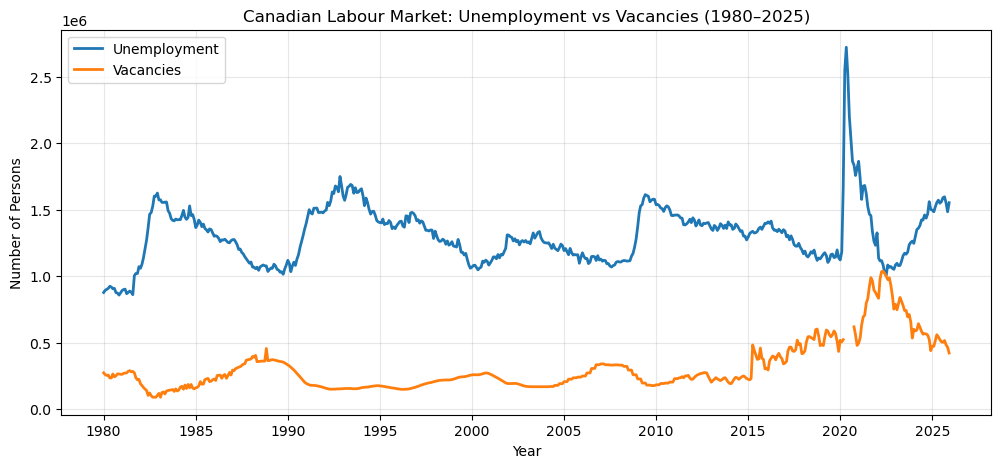

In [183]:
# ============================================================
# STEP D4 — Labour demand vs labour supply over time
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(des_df["month"], des_df["unemployment"], label="Unemployment", linewidth=2)
plt.plot(des_df["month"], des_df["vacancies"], label="Vacancies", linewidth=2)

plt.title("Canadian Labour Market: Unemployment vs Vacancies (1980–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Persons")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

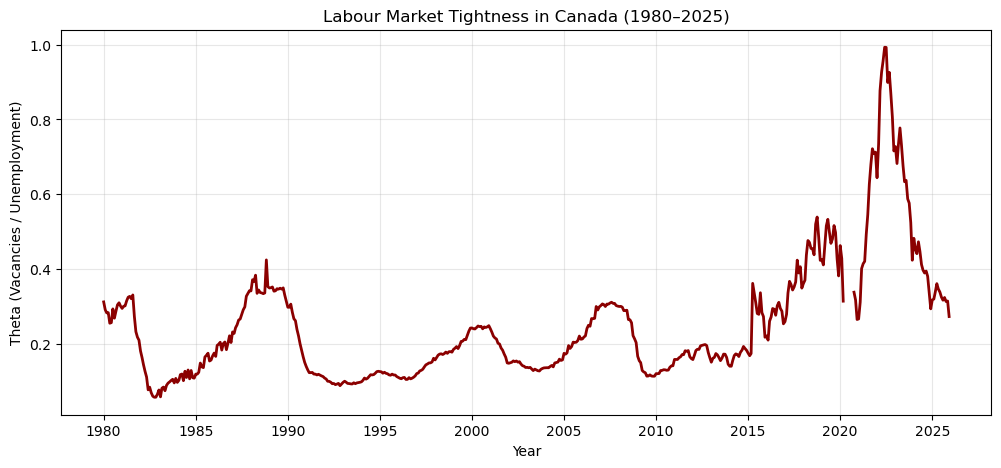

In [184]:
# ============================================================
# STEP D5 — Labour market tightness over time
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(des_df["month"], des_df["theta"], color="darkred", linewidth=2)

plt.title("Labour Market Tightness in Canada (1980–2025)")
plt.xlabel("Year")
plt.ylabel("Theta (Vacancies / Unemployment)")
plt.grid(alpha=0.3)

plt.show()

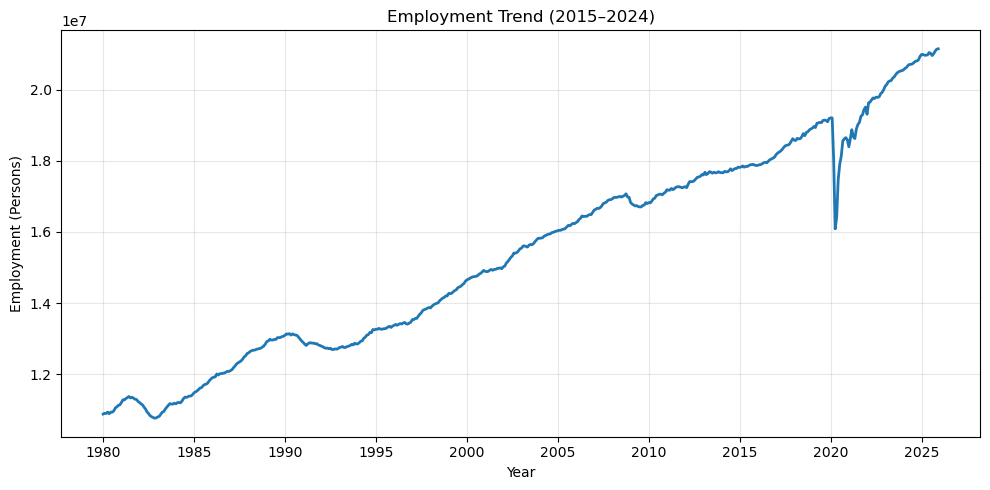

In [185]:
# ============================================================
# Employment Trend Over Time
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["employment"], linewidth=2)

plt.title("Employment Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Employment (Persons)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


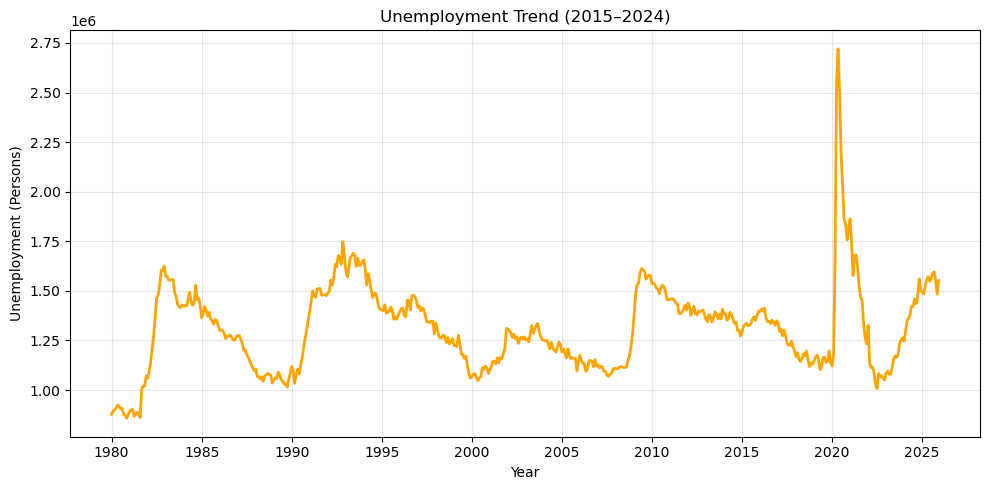

In [186]:
# ============================================================
# Unemployment Trend Over Time
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["unemployment"], linewidth=2, color="orange")

plt.title("Unemployment Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Unemployment (Persons)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


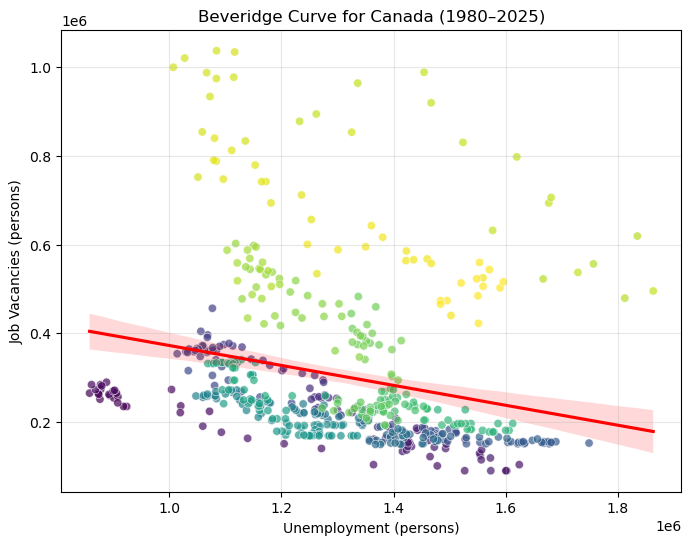

In [187]:
# ============================================================
# STEP D6 — Beveridge Curve with trend line
# ============================================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=des_df,
    x="unemployment",
    y="vacancies",
    hue=des_df["month"].dt.year,
    palette="viridis",
    alpha=0.7,
    legend=False
)

# Add regression trend
sns.regplot(
    data=des_df,
    x="unemployment",
    y="vacancies",
    scatter=False,
    color="red"
)

plt.title("Beveridge Curve for Canada (1980–2025)")
plt.xlabel("Unemployment (persons)")
plt.ylabel("Job Vacancies (persons)")
plt.grid(alpha=0.3)

plt.show()

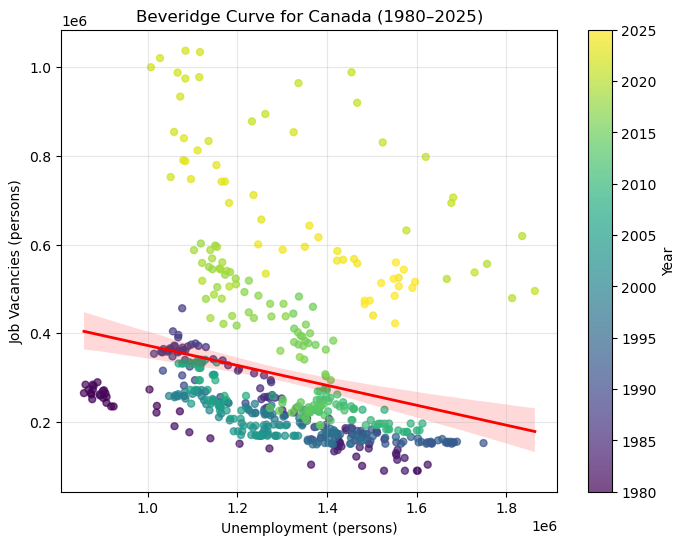

In [188]:
# ============================================================
# STEP D6 — Beveridge Curve with regression and color legend
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

plt.figure(figsize=(8,6))

# Create color normalization for years
years = des_df["month"].dt.year
norm = colors.Normalize(vmin=years.min(), vmax=years.max())
cmap = cm.viridis

# Scatter plot
sc = plt.scatter(
    des_df["unemployment"],
    des_df["vacancies"],
    c=years,
    cmap=cmap,
    norm=norm,
    alpha=0.7,
    s=25
)

# Regression line
sns.regplot(
    data=des_df,
    x="unemployment",
    y="vacancies",
    scatter=False,
    color="red",
    line_kws={"linewidth":2}
)

# Colorbar (legend)
cbar = plt.colorbar(sc)
cbar.set_label("Year")

plt.title("Beveridge Curve for Canada (1980–2025)")
plt.xlabel("Unemployment (persons)")
plt.ylabel("Job Vacancies (persons)")
plt.grid(alpha=0.3)

plt.show()

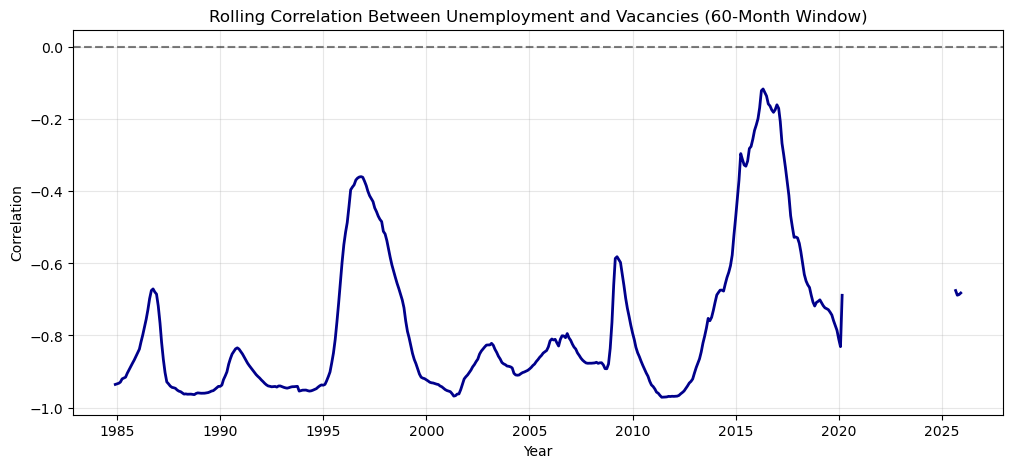

In [202]:
# ============================================================
# STEP D7 — Rolling Beveridge relationship (60-month window)
# ============================================================

window = 60   # 5-year rolling window

rolling_corr = (
    des_df["unemployment"]
    .rolling(window)
    .corr(des_df["vacancies"])
)

plt.figure(figsize=(12,5))

plt.plot(des_df["month"], rolling_corr, color="darkblue", linewidth=2)

plt.axhline(0, linestyle="--", color="black", alpha=0.5)

plt.title("Rolling Correlation Between Unemployment and Vacancies (60-Month Window)")
plt.xlabel("Year")
plt.ylabel("Correlation")

plt.grid(alpha=0.3)

plt.show()

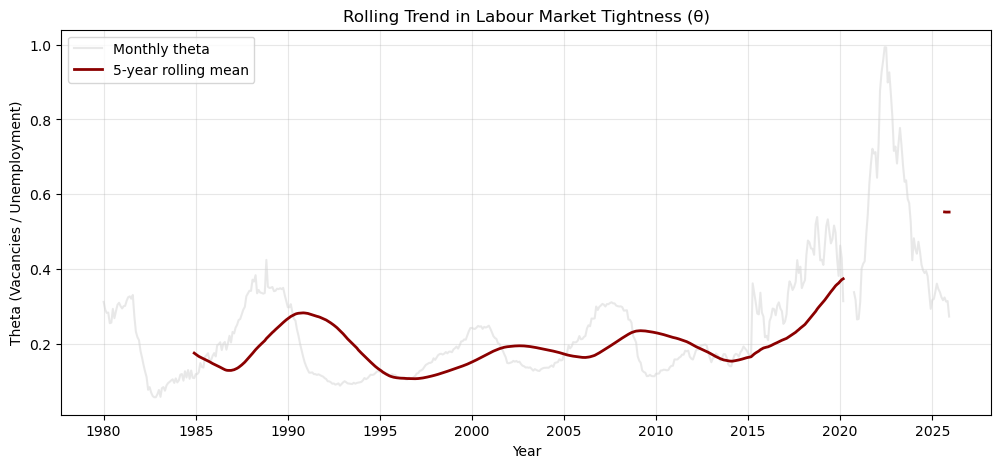

In [203]:
# ============================================================
# STEP D8 — Rolling labour market tightness (trend)
# ============================================================

window = 60  # 5-year smoothing

theta_trend = des_df["theta"].rolling(window).mean()

plt.figure(figsize=(12,5))

plt.plot(des_df["month"], des_df["theta"], color="lightgray", alpha=0.5, label="Monthly theta")
plt.plot(des_df["month"], theta_trend, color="darkred", linewidth=2, label="5-year rolling mean")

plt.title("Rolling Trend in Labour Market Tightness (θ)")
plt.xlabel("Year")
plt.ylabel("Theta (Vacancies / Unemployment)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

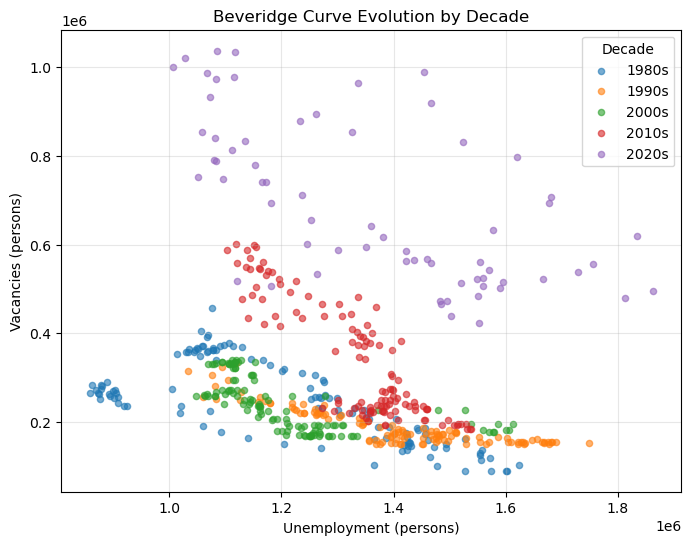

In [204]:
# ============================================================
# STEP D9 — Beveridge curve by decade
# ============================================================

des_df["decade"] = (des_df["month"].dt.year // 10) * 10

plt.figure(figsize=(8,6))

for decade, group in des_df.groupby("decade"):
    plt.scatter(
        group["unemployment"],
        group["vacancies"],
        label=f"{decade}s",
        alpha=0.6,
        s=20
    )

plt.title("Beveridge Curve Evolution by Decade")
plt.xlabel("Unemployment (persons)")
plt.ylabel("Vacancies (persons)")
plt.legend(title="Decade")
plt.grid(alpha=0.3)

plt.show()

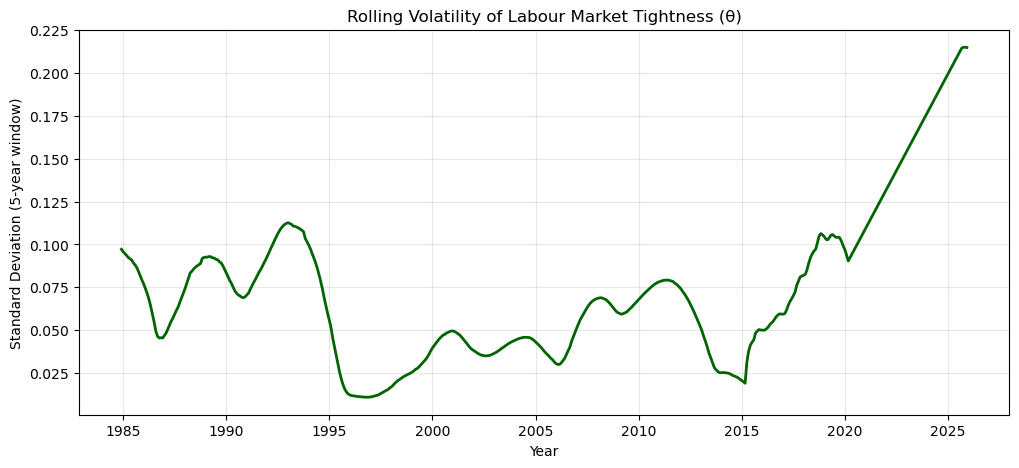

In [209]:
# ============================================================
# STEP D10 — Rolling volatility of labour market tightness
# ============================================================

window = 60  # five-year window

theta_vol = (
    des_df["theta"]
    .rolling(window, min_periods=window)
    .std()
)

theta_vol = theta_vol.dropna()   # remove incomplete windows

plt.figure(figsize=(12,5))
plt.plot(des_df.loc[theta_vol.index, "month"], theta_vol,
         color="darkgreen", linewidth=2)

plt.title("Rolling Volatility of Labour Market Tightness (θ)")
plt.xlabel("Year")
plt.ylabel("Standard Deviation (5-year window)")
plt.grid(alpha=0.3)

plt.show()

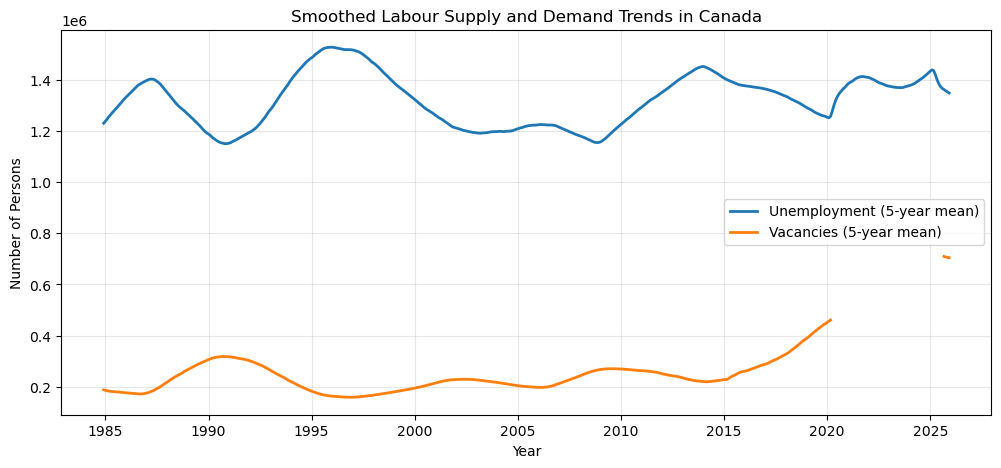

In [210]:
# ============================================================
# STEP D11 — Smoothed unemployment and vacancy trends
# ============================================================

window = 60  # 5-year smoothing window

u_trend = des_df["unemployment"].rolling(window).mean()
v_trend = des_df["vacancies"].rolling(window).mean()

plt.figure(figsize=(12,5))

plt.plot(des_df["month"], u_trend, label="Unemployment (5-year mean)", linewidth=2)
plt.plot(des_df["month"], v_trend, label="Vacancies (5-year mean)", linewidth=2)

plt.title("Smoothed Labour Supply and Demand Trends in Canada")
plt.xlabel("Year")
plt.ylabel("Number of Persons")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [211]:
# ============================================================
# STEP D12 — Pre vs Post COVID labour market comparison
# ============================================================

# Check missing values
print("Missing values per column:")
print(des_df.isna().sum())

# Create a period classification without altering the dataset
des_df["period"] = np.where(
    des_df["month"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "Post-COVID"
)

# Exclude the COVID gap only for the calculation (not from dataset)
analysis_df = des_df.loc[
    ~((des_df["month"] >= "2020-04-01") &
      (des_df["month"] <= "2020-09-30"))
].copy()

# Compute summary statistics by period
period_summary = (
    analysis_df
    .groupby("period")[["employment","unemployment","vacancies","theta"]]
    .mean()
    .round(2)
)

period_summary

Missing values per column:
month           0
employment      0
unemployment    0
labour_force    0
population      0
vacancies       6
theta           6
decade          0
dtype: int64


,employment,unemployment,vacancies,theta
period,,,,
Post-COVID,20056850.0,1373896.88,694526.17,0.54
Pre-COVID,14751202.7,1289403.32,253637.13,0.21


## Correlation Analysis

This section examines the correlation structure among:

- Employment
- Unemployment
- Job Vacancies
- Labour Market Imbalance (θ)

Correlation coefficients help quantify the strength and direction of relationships observed in the previous visualizations.


Correlation Matrix:


,employment,unemployment,labour_force,population,vacancies,theta
employment,1.000,0.080,0.997,0.991,0.666,0.567
unemployment,0.080,1.000,0.154,0.185,-0.235,-0.443
labour_force,0.997,0.154,1.000,0.996,0.647,0.534
population,0.991,0.185,0.996,1.000,0.664,0.547
vacancies,0.666,-0.235,0.647,0.664,1.000,0.965
theta,0.567,-0.443,0.534,0.547,0.965,1.000


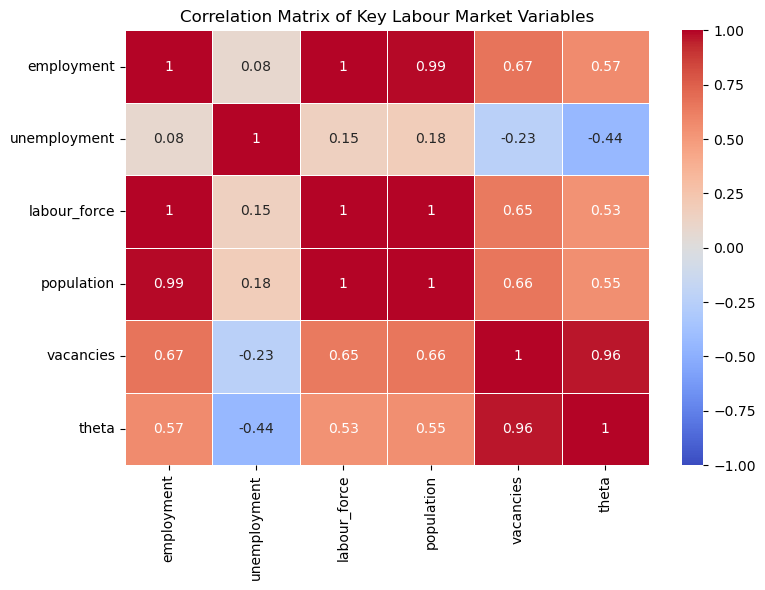


Key Relationships:
Correlation between Unemployment and Vacancies: -0.235
Correlation between Unemployment and Theta: -0.443


In [214]:
# ============================================================
# STEP D13 — Correlation Matrix of Labour Market Variables
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select variables
corr_vars = [
    "employment",
    "unemployment",
    "labour_force",
    "population",
    "vacancies",
    "theta"
]

# Compute correlation matrix
corr_matrix = des_df[corr_vars].corr().round(3)

# Display numerical table
print("Correlation Matrix:")
display(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Key Labour Market Variables")
plt.tight_layout()
plt.show()

# Highlight key relationships
print("\nKey Relationships:")
print("Correlation between Unemployment and Vacancies:", corr_matrix.loc["unemployment","vacancies"])
print("Correlation between Unemployment and Theta:", corr_matrix.loc["unemployment","theta"])

In [216]:
# ============================================================
# ============================================================
# PHASE 1.1 — CORE METRICS (Counts → Indicators)
# ============================================================

# ---- Column mapping ----
COL_MONTH = "month"
COL_E     = "employment"
COL_U     = "unemployment"
COL_LF    = "labour_force"
COL_POP   = "population"
COL_V     = "vacancies"

required = [COL_MONTH, COL_E, COL_U, COL_LF, COL_POP, COL_V]

missing_cols = [c for c in required if c not in des_df.columns]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n"
        f"Available columns: {list(des_df.columns)}"
    )

# ---- Convert numeric columns safely ----
for c in [COL_E, COL_U, COL_LF, COL_POP, COL_V]:
    des_df[c] = pd.to_numeric(des_df[c], errors="coerce")

# ---- Convert date ----
des_df[COL_MONTH] = pd.to_datetime(des_df[COL_MONTH])

# ---- Sort dataset ----
des_df = des_df.sort_values(COL_MONTH).reset_index(drop=True)

# ============================================================
# Construct labour market indicators
# ============================================================

# Labour market tightness
des_df["theta"] = des_df[COL_V] / des_df[COL_U]

# Unemployment rate
des_df["ur"] = des_df[COL_U] / des_df[COL_LF]

# Labour force participation rate
des_df["lfpr"] = des_df[COL_LF] / des_df[COL_POP]

# Employment-to-population ratio
des_df["epop"] = des_df[COL_E] / des_df[COL_POP]

# ============================================================
# Sanity checks (important for academic work)
# ============================================================

print("Dataset range:")
print(des_df[COL_MONTH].min(), "→", des_df[COL_MONTH].max())

print("\nMissing values after indicator creation:")
print(des_df[["theta","ur","lfpr","epop"]].isna().sum())

print("\nBasic summary of indicators:")
display(des_df[["theta","ur","lfpr","epop"]].describe().round(3))

print("\nIndicators successfully created")
des_df.head()

Dataset range:
1980-01-01 00:00:00 → 2025-12-01 00:00:00

Missing values after indicator creation:
theta    6
ur       0
lfpr     0
epop     0
dtype: int64

Basic summary of indicators:


,theta,ur,lfpr,epop
count,546.000,552.000,552.000,552.000
mean,0.245,0.081,0.660,0.607
std,0.160,0.018,0.010,0.018
min,0.056,0.048,0.601,0.519
25%,0.132,0.069,0.653,0.594
50%,0.195,0.076,0.659,0.613
75%,0.308,0.093,0.669,0.620
max,0.993,0.142,0.677,0.636



Indicators successfully created


,month,employment,unemployment,labour_force,population,vacancies,theta,decade,period,theta_growth,bev_corr_rolling,ur,lfpr,epop
0,1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504,1980,Pre-COVID,NaN,NaN,0.074617,0.642000,0.594096
1,1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468,1980,Pre-COVID,-0.067533,NaN,0.075783,0.643009,0.594280
2,1980-03-01,10897800,901000,11798900,18373900,254211.0,0.282143,1980,Pre-COVID,-0.028659,NaN,0.076363,0.642155,0.593113
3,1980-04-01,10938300,908300,11846700,18407700,256944.0,0.282885,1980,Pre-COVID,0.002628,NaN,0.076671,0.643573,0.594224
4,1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440,1980,Pre-COVID,-0.100552,NaN,0.078194,0.640858,0.590747


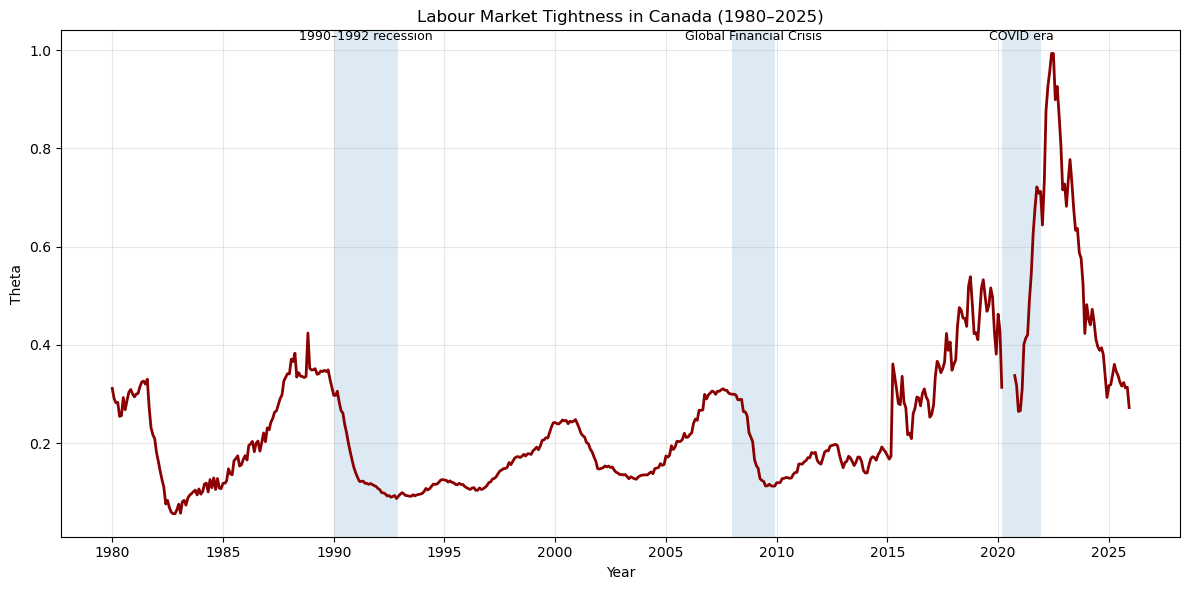

In [217]:
plt.figure(figsize=(12,6))

plt.plot(
    des_df["month"],
    des_df["theta"],
    color="darkred",
    linewidth=2
)

ax = plt.gca()

# add shaded macro events
add_event_shading(ax)

plt.title("Labour Market Tightness in Canada (1980–2025)")
plt.xlabel("Year")
plt.ylabel("Theta")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [218]:
def plot_series(df, x, y, title, ylabel, filename, percent=False):

    plt.figure(figsize=(11,5.5))

    ax = plt.gca()

    ax.plot(df[x], df[y], linewidth=1.6)

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)

    if percent:
        ax.yaxis.set_major_formatter(
            lambda val, pos: f"{val*100:.1f}%"
        )

    add_event_shading(ax)

    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    path = FIG_DIR / filename

    plt.savefig(path, dpi=300)

    plt.show()

    return path

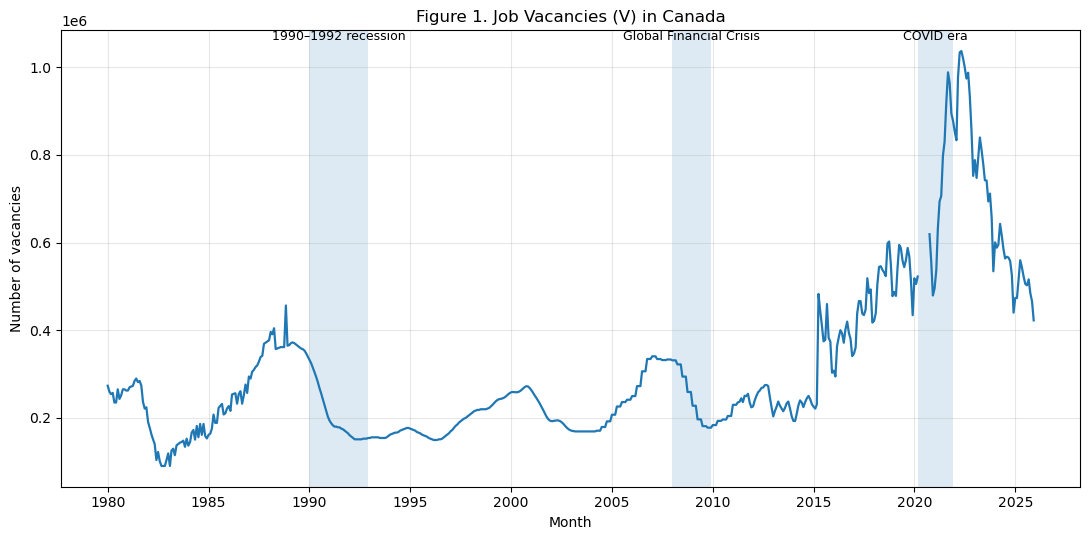

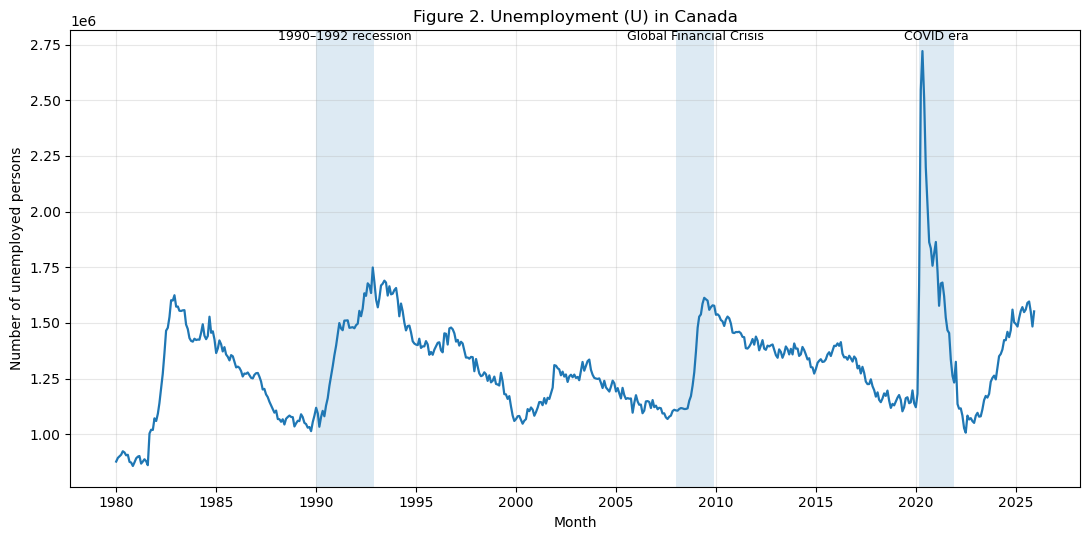

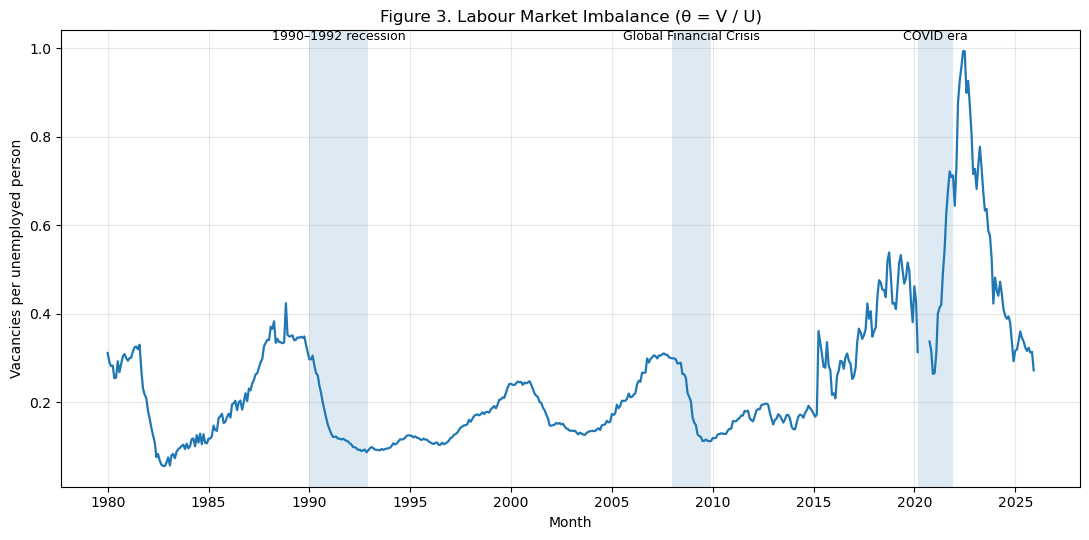

WindowsPath('figures/phase1_descriptive/fig03_theta.png')

In [219]:
plot_series(
    des_df,
    "month",
    "vacancies",
    "Figure 1. Job Vacancies (V) in Canada",
    "Number of vacancies",
    "fig01_vacancies.png"
)

plot_series(
    des_df,
    "month",
    "unemployment",
    "Figure 2. Unemployment (U) in Canada",
    "Number of unemployed persons",
    "fig02_unemployment.png"
)

plot_series(
    des_df,
    "month",
    "theta",
    "Figure 3. Labour Market Imbalance (θ = V / U)",
    "Vacancies per unemployed person",
    "fig03_theta.png"
)

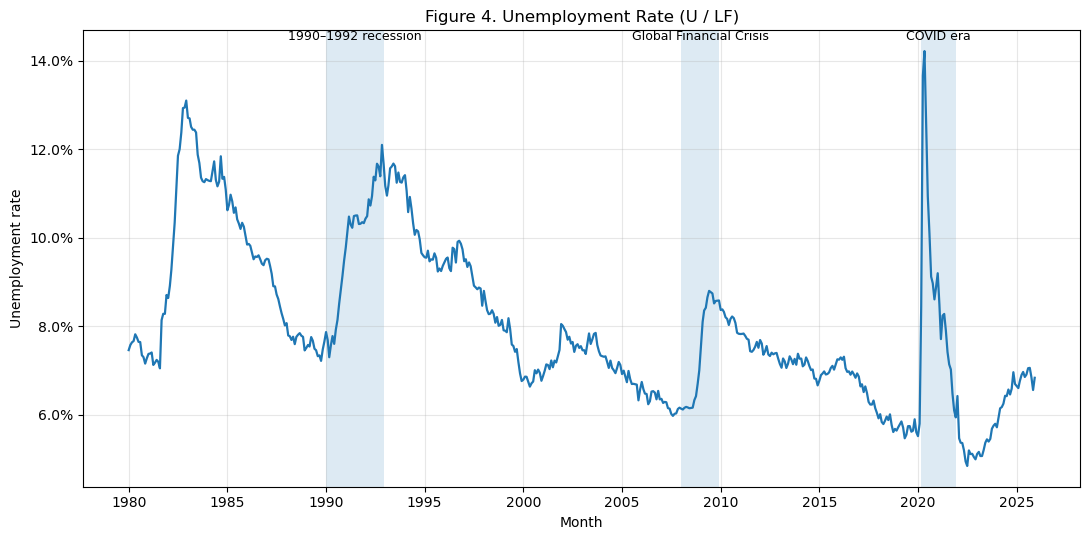

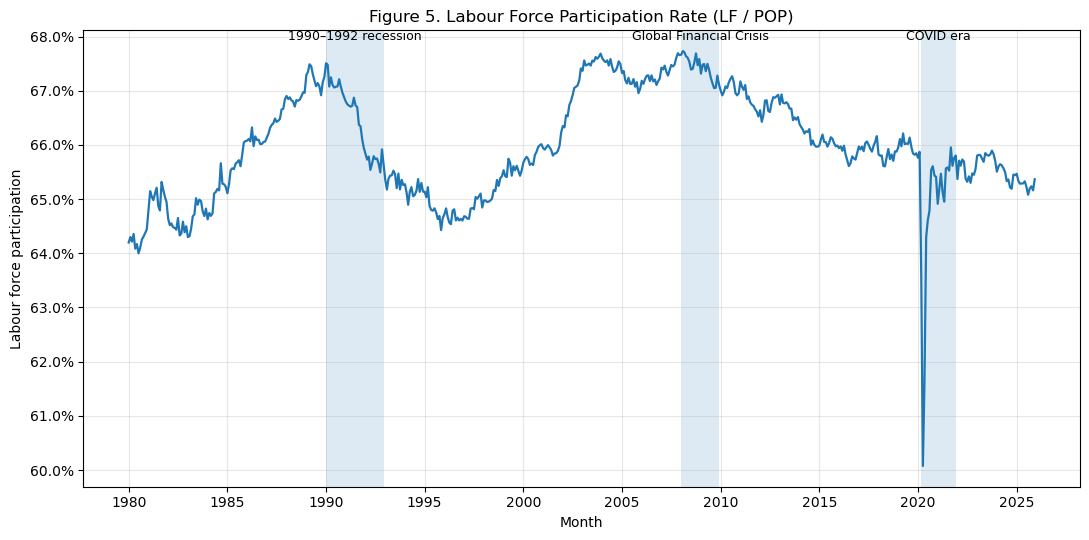

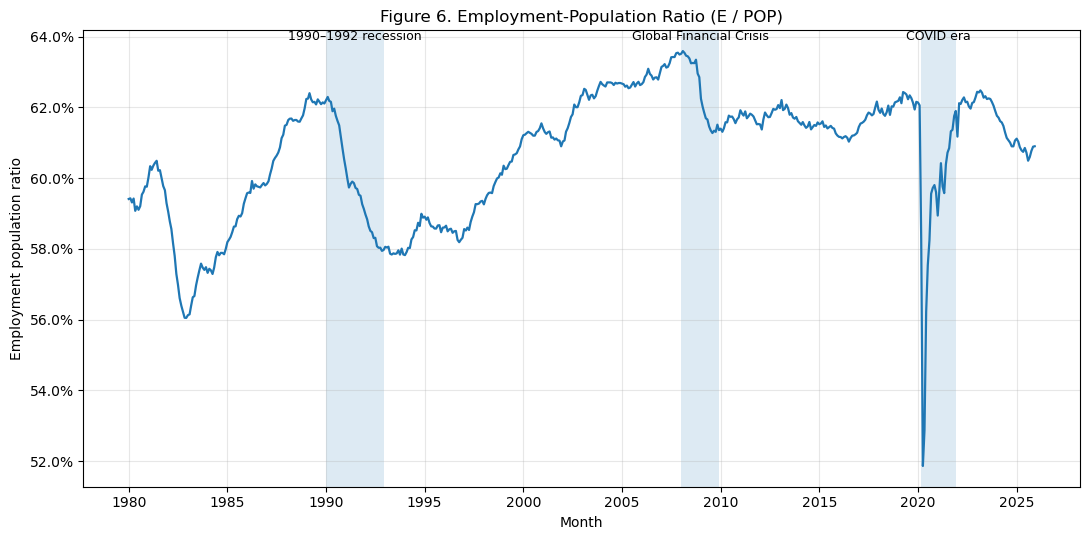

WindowsPath('figures/phase1_descriptive/fig06_epop.png')

In [220]:
plot_series(
    des_df,
    "month",
    "ur",
    "Figure 4. Unemployment Rate (U / LF)",
    "Unemployment rate",
    "fig04_unemployment_rate.png",
    percent=True
)

plot_series(
    des_df,
    "month",
    "lfpr",
    "Figure 5. Labour Force Participation Rate (LF / POP)",
    "Labour force participation",
    "fig05_lfpr.png",
    percent=True
)

plot_series(
    des_df,
    "month",
    "epop",
    "Figure 6. Employment-Population Ratio (E / POP)",
    "Employment population ratio",
    "fig06_epop.png",
    percent=True
)

In [221]:
# ============================================================
# TABLE 1 — SUMMARY STATISTICS
# ============================================================

import numpy as np
from pathlib import Path

TABLE_DIR = Path("exports/phase1_descriptive")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

variables = [
    "employment",
    "unemployment",
    "labour_force",
    "population",
    "vacancies",
    "theta",
    "ur",
    "lfpr",
    "epop"
]

summary_rows = []

for var in variables:
    
    series = des_df[var].dropna()
    
    summary_rows.append({
        "variable": var,
        "mean": series.mean(),
        "sd": series.std(),
        "p1": series.quantile(0.01),
        "p99": series.quantile(0.99),
        "min": series.min(),
        "max": series.max(),
        "n_obs": len(series)
    })

summary_table = pd.DataFrame(summary_rows)

summary_table = summary_table.round(4)

summary_table

,variable,mean,sd,p1,p99,min,max,n_obs
0,employment,1.539541e+07,2.895924e+06,1.082743e+07,2.099817e+07,1.076410e+07,2.114600e+07,552
1,unemployment,1.310311e+06,2.190779e+05,8.767100e+05,1.862839e+06,8.577000e+05,2.720500e+06,552
2,labour_force,1.670572e+07,2.921633e+06,1.185098e+07,2.256208e+07,1.176010e+07,2.269770e+07,552
3,population,2.530230e+07,4.389837e+06,1.848787e+07,3.459562e+07,1.831790e+07,3.472300e+07,552
4,vacancies,3.053164e+05,1.823114e+05,1.038710e+05,9.831722e+05,9.020400e+04,1.037195e+06,546
5,theta,2.454000e-01,1.600000e-01,7.080000e-02,8.890000e-01,5.630000e-02,9.934000e-01,546
6,ur,8.050000e-02,1.820000e-02,5.090000e-02,1.270000e-01,4.840000e-02,1.422000e-01,552
7,lfpr,6.600000e-01,9.900000e-03,6.414000e-01,6.766000e-01,6.007000e-01,6.773000e-01,552
8,epop,6.069000e-01,1.780000e-02,5.619000e-01,6.347000e-01,5.187000e-01,6.359000e-01,552


In [152]:
summary_table.to_csv(
    TABLE_DIR / "table01_summary_statistics.csv",
    index=False
)

In [222]:
# ============================================================
# TABLE 2 — REGIME SUMMARY
# ============================================================

regimes = [

    ("1980–1989", "1980-01-01", "1989-12-01"),
    ("1990–1992 recession", "1990-01-01", "1992-12-01"),
    ("1993–2007 expansion", "1993-01-01", "2007-12-01"),
    ("2008–2009 crisis", "2008-01-01", "2009-12-01"),
    ("2010–2019 recovery", "2010-01-01", "2019-12-01"),
    ("COVID shock", "2020-03-01", "2021-12-01"),
    ("Post-COVID tightening", "2022-01-01", "2025-12-01")

]

rows = []

for name, start, end in regimes:
    
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    subset = des_df[
        (des_df["month"] >= start) &
        (des_df["month"] <= end)
    ]
    
    if subset.empty:
        continue
    
    rows.append({
        "regime": name,
        "start": subset["month"].min(),
        "end": subset["month"].max(),
        "months": len(subset),
        "theta_mean": subset["theta"].mean(),
        "theta_sd": subset["theta"].std(),
        "ur_mean": subset["ur"].mean(),
        "lfpr_mean": subset["lfpr"].mean(),
        "epop_mean": subset["epop"].mean()
    })

regime_table = pd.DataFrame(rows).round(4)

regime_table

,regime,start,end,months,theta_mean,theta_sd,ur_mean,lfpr_mean,epop_mean
0,1980–1989,1980-01-01,1989-12-01,120,0.2190,0.1015,0.0938,0.6558,0.5944
1,1990–1992 recession,1990-01-01,1992-12-01,36,0.1516,0.0706,0.0989,0.6647,0.5991
2,1993–2007 expansion,1993-01-01,2007-12-01,180,0.1714,0.0609,0.0811,0.6606,0.6072
3,2008–2009 crisis,2008-01-01,2009-12-01,24,0.1960,0.0758,0.0739,0.6743,0.6245
4,2010–2019 recovery,2010-01-01,2019-12-01,120,0.2620,0.1232,0.0695,0.6631,0.6170
5,COVID shock,2020-03-01,2021-12-01,22,0.4707,0.1711,0.0888,0.6484,0.5911
6,Post-COVID tightening,2022-01-01,2025-12-01,48,0.5588,0.2269,0.0596,0.6551,0.6161


In [154]:
regime_table.to_csv(
    TABLE_DIR / "table02_regime_summary.csv",
    index=False
)

In [223]:
# ============================================================
# TABLE 3 — MISSING DATA AUDIT
# ============================================================

missing_rows = []

for col in variables:
    
    missing = des_df.loc[
        des_df[col].isna(),
        "month"
    ]
    
    missing_rows.append({
        "variable": col,
        "missing_count": len(missing),
        "missing_months": ", ".join(
            missing.dt.strftime("%Y-%m").tolist()
        )
    })

missing_table = pd.DataFrame(missing_rows)

missing_table

,variable,missing_count,missing_months
0,employment,0,
1,unemployment,0,
2,labour_force,0,
3,population,0,
4,vacancies,6,"2020-04, 2020-05, 2020-06, 2020-07, 2020-08, 2..."
5,theta,6,"2020-04, 2020-05, 2020-06, 2020-07, 2020-08, 2..."
6,ur,0,
7,lfpr,0,
8,epop,0,


In [224]:
missing_table.to_csv(
    TABLE_DIR / "table03_missing_data.csv",
    index=False
)

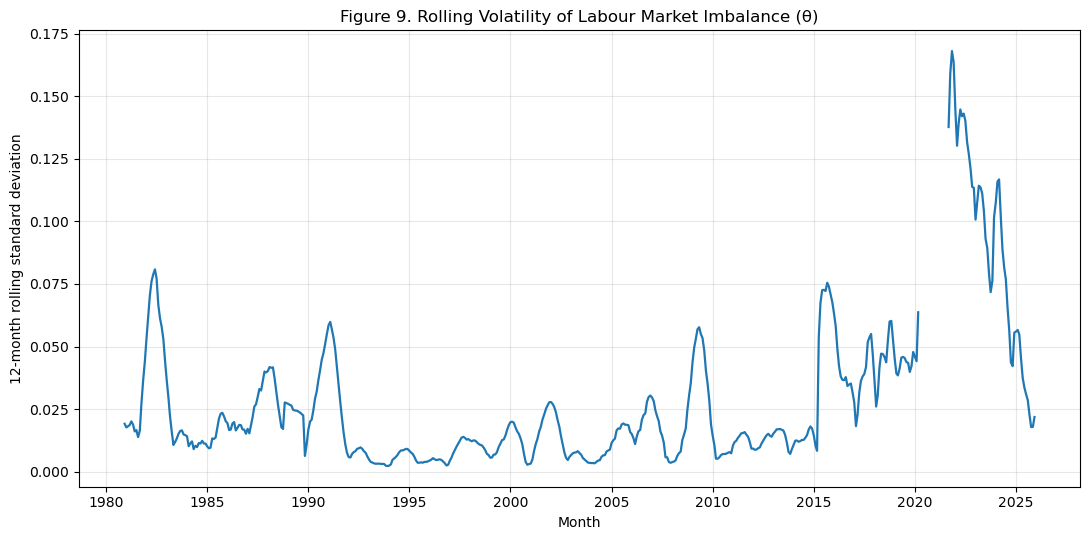

WindowsPath('figures/phase1_descriptive/fig09_theta_volatility.png')

In [226]:
# ============================================================
# FIGURE — ROLLING VOLATILITY OF LABOUR MARKET IMBALANCE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("figures/phase1_descriptive")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 12-month rolling standard deviation
des_df["theta_volatility"] = des_df["theta"].rolling(12).std()

plt.figure(figsize=(11,5.5))

plt.plot(
    des_df["month"],
    des_df["theta_volatility"],
    linewidth=1.6
)

plt.title("Figure 9. Rolling Volatility of Labour Market Imbalance (θ)")
plt.xlabel("Month")
plt.ylabel("12-month rolling standard deviation")

plt.grid(True, alpha=0.3)

plt.tight_layout()

path = FIG_DIR / "fig09_theta_volatility.png"
plt.savefig(path, dpi=300)

plt.show()

path